In [27]:
import numpy as np
import importlib
import Sim_Parameters
#from config import *
from simulation import run
from visualize import plot_initial, plot_trajectory, plot_force
import numpy as np
from integrator import step
from driving import update_traps
from forces import trap_force
from hydrodynamics import mobility_matrix
from simulation import run
import matplotlib.pyplot as plt

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


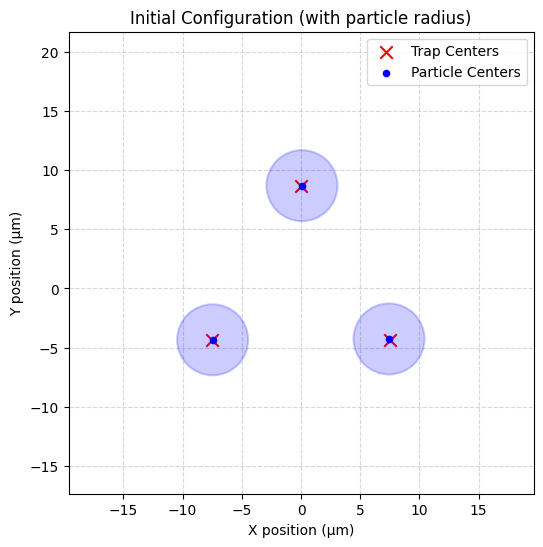

[[ 7.43383415e-06 -4.26117206e-06]
 [ 8.05283570e-08  8.68621997e-06]
 [-7.46545738e-06 -4.33336922e-06]]


In [28]:
importlib.reload(Sim_Parameters)
from Sim_Parameters import *
# Initial visualization
plot_initial(pos0, trap0, a)
print(pos0)

In [29]:
H = mobility_matrix(pos0, eta)
print("Mobility Matrix H:")
print(H)
D = kBT * (H + H.T) / 2  # Ensure symmetry
A = np.linalg.cholesky(D )
print("Cholesky factor A:")
with np.printoptions(precision=2, suppress=False, formatter={'float': '{:.2e}'.format}):
    print(A)

Mobility Matrix H:
[[ 2.00000000e+07  0.00000000e+00  3.75927818e+06 -1.29780987e+06
   6.04041384e+06  1.46347760e+04]
 [ 0.00000000e+00  2.00000000e+07 -1.29780987e+06  5.30733277e+06
   1.46347760e+04  3.02031330e+06]
 [ 3.75927818e+06 -1.29780987e+06  2.00000000e+07  0.00000000e+00
   3.74230608e+06  1.29736649e+06]
 [-1.29780987e+06  5.30733277e+06  0.00000000e+00  2.00000000e+07
   1.29736649e+06  5.22880158e+06]
 [ 6.04041384e+06  1.46347760e+04  3.74230608e+06  1.29736649e+06
   2.00000000e+07  0.00000000e+00]
 [ 1.46347760e+04  3.02031330e+06  1.29736649e+06  5.22880158e+06
   0.00000000e+00  2.00000000e+07]]
Cholesky factor A:
[[2.87e-07 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [0.00e+00 2.87e-07 0.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [5.39e-08 -1.86e-08 2.81e-07 0.00e+00 0.00e+00 0.00e+00]
 [-1.86e-08 7.61e-08 8.61e-09 2.76e-07 0.00e+00 0.00e+00]
 [8.66e-08 2.10e-10 3.82e-08 2.39e-08 2.70e-07 0.00e+00]
 [2.10e-10 4.33e-08 2.18e-08 6.54e-08 -8.99e-09 2.75e-07]]


In [30]:
print(steps)

100000


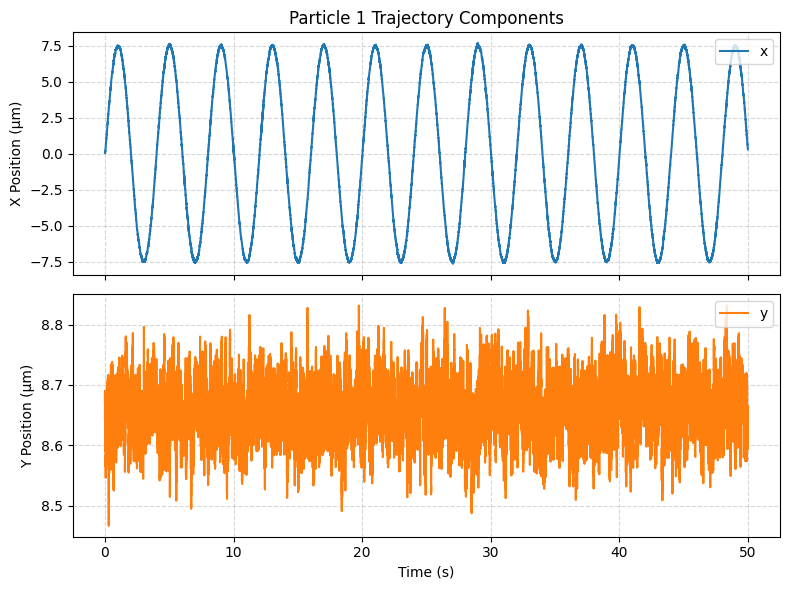

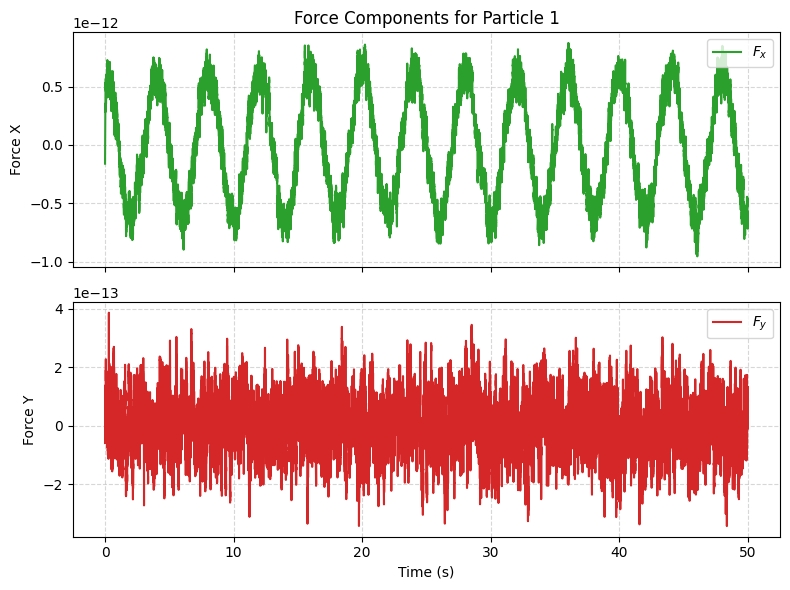

In [31]:
# Run simulation
traj, forces, traps = run(
    pos0,
    trap0,
    kappa,
    drive,
    eta,
    dt,
    steps
)

# After shear
plot_trajectory(traj, dt,particle=1)
plot_force(forces, dt,particle=1)

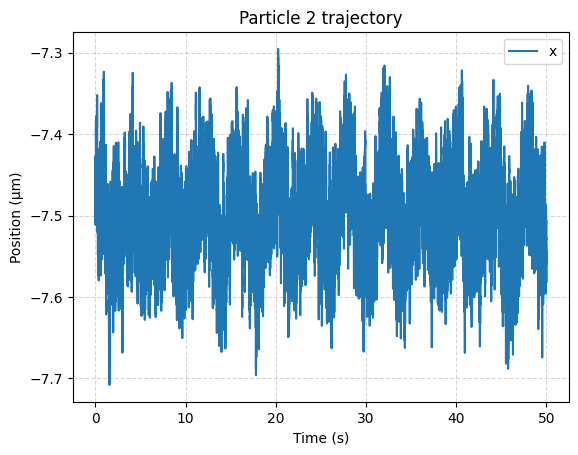

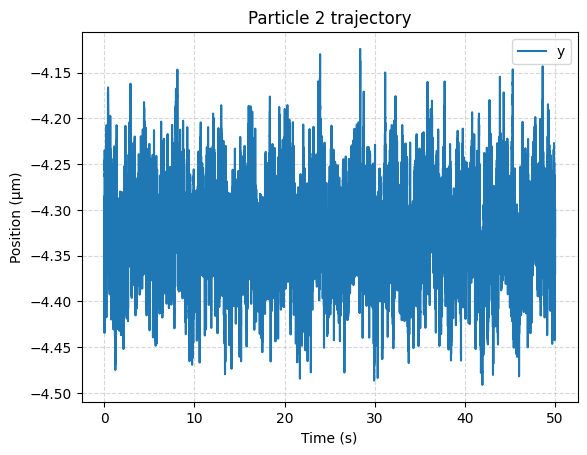

In [32]:
num_steps = len(traj)

    # Create an array of timestamps: [0, dt, 2*dt, ..., (num_steps-1)*dt]
time_axis = np.arange(num_steps) * dt
particle = 2
plt.figure()

    # Plot x  coordinates against the physical time axis
plt.plot(time_axis, traj[:, particle, 0]*1e6, label="x")
    

plt.xlabel("Time (s)")  # Added axis label
plt.ylabel("Position (μm)")
plt.legend()
plt.title(f"Particle {particle} trajectory")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

plt.figure()

# Plot y coordinates against the physical time axis

plt.plot(time_axis, traj[:, particle, 1]*1e6, label="y")

plt.xlabel("Time (s)")  # Added axis label
plt.ylabel("Position (μm)")
plt.legend()
plt.title(f"Particle {particle} trajectory")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

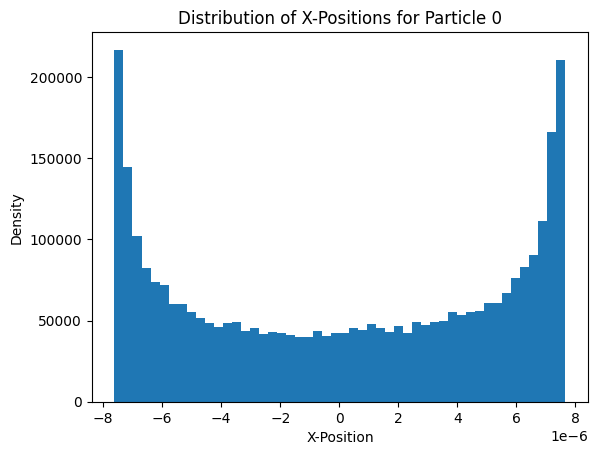

In [33]:
plt.figure()
# Plot histogram of x-positions of particle 0
plt.hist(traj[:, 1, 0], bins=50, density=True)
plt.xlabel("X-Position")
plt.ylabel("Density")
plt.title("Distribution of X-Positions for Particle 0")
plt.show()

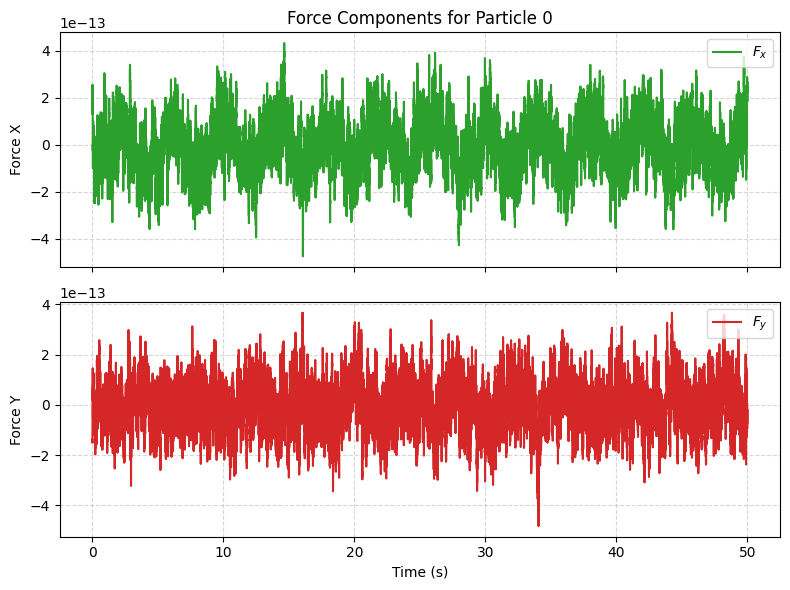

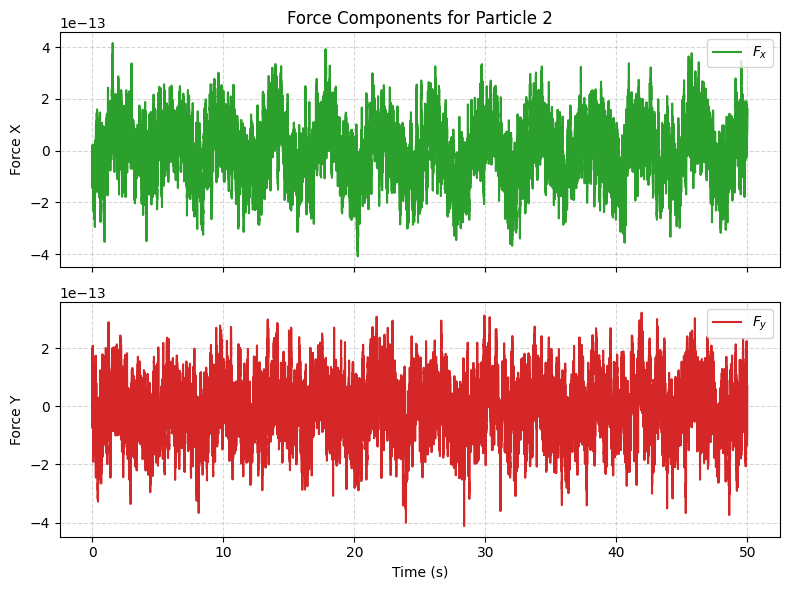

In [34]:
plot_force(forces, dt,particle=0)
plot_force(forces, dt,particle=2)

In [35]:
x = traj[:, 2,0]
print(6 * np.pi * eta * a)
kBT = 1.38e-23 * (273 + 25)
k_eff = kBT / np.var(x)
print(f"Effective stiffness from trajectory: {k_eff:.2e} N/m")

5e-08
Effective stiffness from trajectory: 1.34e-06 N/m


In [36]:
fluctuations = (traj - trap0)*1e6

fluctuations = fluctuations.reshape(fluctuations.shape[0], -1)
C = np.cov(fluctuations.T)
print("Covariance Matrix:\n")
print(C)
diagonal = np.diag(np.diag(C))
offdiag_norm = np.linalg.norm(C - diagonal)
diagonal_norm = np.linalg.norm(diagonal)
print("\nOff-diagonal norm / Diagonal norm =", offdiag_norm/diagonal_norm)

Covariance Matrix:

[[ 3.16705409e-03 -4.66814335e-04  6.18811486e-03 -1.73090363e-05
   9.28204791e-04  5.86389965e-04]
 [-4.66814335e-04  2.24512292e-03 -6.98541797e-03 -7.25331306e-06
  -4.31434169e-04 -2.33093092e-04]
 [ 6.18811486e-03 -6.98541797e-03  2.80362440e+01  4.96441991e-03
  -8.80309291e-04  7.63646441e-04]
 [-1.73090363e-05 -7.25331306e-06  4.96441991e-03  2.09444063e-03
   2.24957999e-05 -1.12803539e-05]
 [ 9.28204791e-04 -4.31434169e-04 -8.80309291e-04  2.24957999e-05
   3.06334540e-03  4.44421166e-04]
 [ 5.86389965e-04 -2.33093092e-04  7.63646441e-04 -1.12803539e-05
   4.44421166e-04  2.25862739e-03]]

Off-diagonal norm / Diagonal norm = 0.0005408271774355809
